# Машинное обучение, ФКН ВШЭ #

## Практическое задание 5. Решающие деревья ##

### Общая информация ###

Дата выдачи: 16.04.2026

Мягкий дедлайн: 30.04.2026 23:59

Жесткий дедлайн:  05.05.2026 23:59

### О задании

В процессе выполнения этого домашнего задания вы:

1. Попрактикуетесь использовать решающие деревья из `sklearn` для задачи классификации на простых двумерных датасетах, научитесь визуализировать разделяющие плоскости и распознавать переобучение.

2. Реализуете своё решающее дерево для задачи классификации и сравните его со стандартной имплементацией.

3. Исследуете влияние бэггинга на смещение и разброс.

### Оценивание и штрафы

Каждая из задач имеет определенную стоимость, которая указана в скобках около номера задачи. Максимально допустимая оценка за работу $-$ 10 баллов.

Задание выполняется самостоятельно. "Похожие" решения считаются плагиатом: все задействованные студенты (в том числе те, у кого списали) получают не более 0 баллов. Если вы использовали внешний источник (даже частично), укажите ссылку в отдельном блоке в конце работы.

Неэффективная реализация кода может негативно отразиться на оценке.

**Устная проверка.** Для проверки понимания кода и выводов студент может быть приглашён на устную защиту. Оценка за задание может быть изменена после устной защиты. Если студент не может объяснить ключевые части решения и принятые решения, работа считается недобросовестной и оценивается в 0 баллов независимо от автотестов.


### Формат сдачи

Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-05-trees-Username.ipynb
* Модуль hw5code.py
* Номера лучших посылок в Яндекс.Контесте для обеих задач

В **ССЫЛКА НА КОНТЕСТ** нужно отправить файл hw5code.py с реализованными функциями и классами.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже:

__Оценка:__ 10

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(0)

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
sns.set(style='whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Решающие деревья

### Визуализация (1 балл)

Рассмотрим три простых двумерных датасета, сгенерированных с помощью `make_moons`, `make_circles` и `make_classification`.

In [117]:
from sklearn.datasets import make_moons, make_circles, make_classification

datasets = [
    make_circles(noise=0.2, factor=0.5, random_state=42),
    make_moons(noise=0.2, random_state=42),
    make_classification(n_classes=3, n_clusters_per_class=1, n_features=2,
                        class_sep=0.75, random_state=3, n_redundant=0)
]

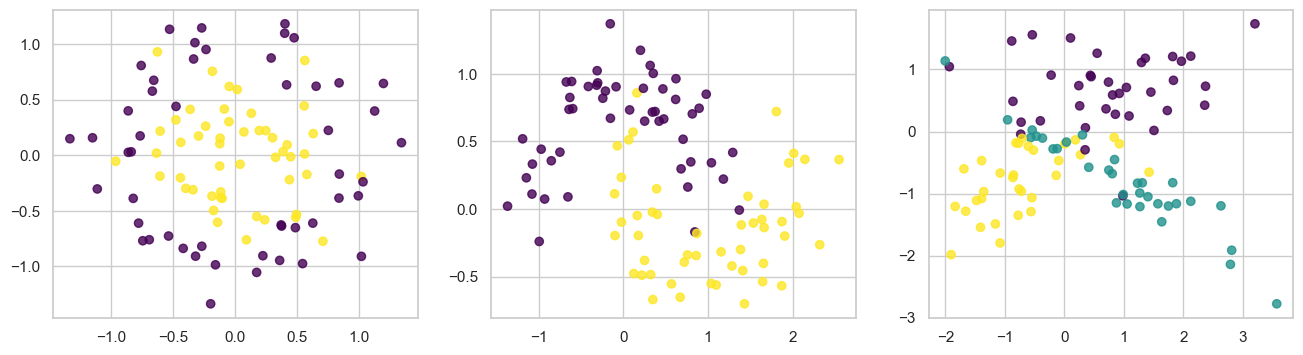

In [118]:
plt.figure(figsize=(16, 4))
for i, (x, y) in enumerate(datasets):
    plt.subplot(1, 3, i + 1)
    plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis", alpha=0.8)

__Задание 1. (0.5 балла)__

Для каждого датасета обучите решающее дерево с параметрами по умолчанию, предварительно разбив выборку на обучающую и тестовую. Постройте разделящие поверхности и посчитайте accuracy на обучающей и тестовой выборках. Прокомментируйте, в каких случаях и почему модель переобучается.

Circles:
Train accuracy = 1.0
Test accuracy  = 0.65

Moons:
Train accuracy = 1.0
Test accuracy  = 0.9

Classification:
Train accuracy = 1.0
Test accuracy  = 0.7



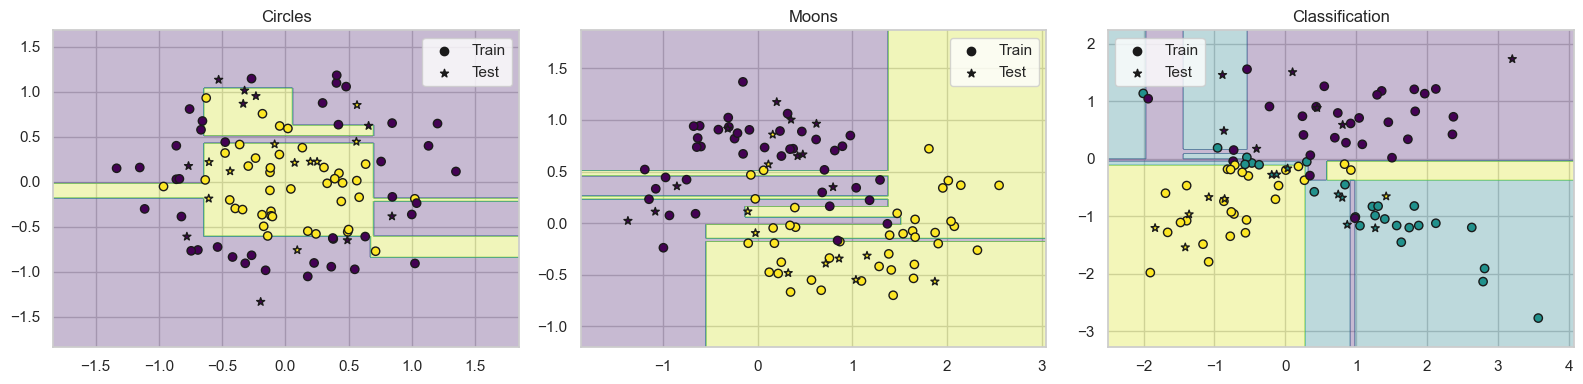

In [122]:
from sklearn.metrics import accuracy_score

names = ["Circles", "Moons", "Classification"]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for i, (name, (X, y)) in enumerate(zip(names, datasets)):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    tree = DecisionTreeClassifier(random_state=42)
    tree.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))

    print(f"{name}:")
    print(f"Train accuracy = {train_acc}")
    print(f"Test accuracy  = {test_acc}\n")

    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300)
    )

    z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax[i].contourf(xx, yy, z, alpha=0.3, cmap="viridis")

    ax[i].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", edgecolor='k', marker="o")
    ax[i].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="viridis", edgecolor='k', marker="*")

    ax[i].scatter([], [], c='k', marker='o', label='Train')
    ax[i].scatter([], [], c='k', marker='*', label='Test')
    ax[i].legend()
    
    ax[i].set_title(f"{name}")

plt.tight_layout()
plt.show()

__Ответ:__

Во всех случаях деревья с параметрами по умолчанию идеально подстроились под данные (везде на train_acc = 1), это ещё выражается в том, что плоскости получились с тонкими полосами под конкретные точки. Это говорит о том, что дерево выделило не общие черты, а конкретные особенности обучеющей выборки, из-за чего была плохая обобщающая способность, то есть произошло сильное переобучение.

Самая худшая обощающая способность была у кругов, возможно это связано с тем, что фигуру круга сложно очертить с помощью горизонтальных и вертикальных полос, поэтому модель пошла по лёгкому пути - выделила основной прямоугольник центрального круга, а выбивающиеся точки выделила узкими полосами. Естественно на тестовой выборке это дало много ошибок.

Почти так же плохо было с 3 датасетом (classification), но тут это наверно связано с тем, что там сложные накладывающиеся друг на друга классы. 

__Задание 2. (0.5 балла)__

Выберите один датасет из предыдущего задания и исследуйте на его примере влияние на итоговое качество двух гиперпараметров (любых на ваш выбор) одновременно. Для каждой пары значений посчитайте accuracy на обучающей и тестовой выборках и сохраните результаты в таблицу.

Визуализируйте зависимость качества на тестовой выборке от значений выбранных вами гиперпараметров. При каких значениях наблюдается лучшее соотношение разброса и смещения? Почему вы сделали такой вывод?

In [19]:
import pandas as pd

res_table = []
max_depth_arr =  [2, 3, 5, 10]
min_samples_leaf_arr = [1, 2, 3, 5, 10]

X, y = datasets[0]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

for depth in max_depth_arr:
    for sample_leaf in min_samples_leaf_arr:
        tree = DecisionTreeClassifier(max_depth=depth, min_samples_leaf=sample_leaf, random_state=42)
        tree.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, tree.predict(X_train))
        test_acc = accuracy_score(y_test, tree.predict(X_test))
        res_table.append({
            "max_depth" : depth,
            "min_samples_leaf" : sample_leaf,
            "train_acc" : train_acc,
            "test_acc" : test_acc
        })

res = pd.DataFrame(res_table)

In [20]:
res

,max_depth,min_samples_leaf,train_acc,test_acc
0,2,1,0.7875,0.65
1,2,2,0.7875,0.65
2,2,3,0.7875,0.65
3,2,5,0.7875,0.65
4,2,10,0.7875,0.65
5,3,1,0.8875,0.70
6,3,2,0.8750,0.70
7,3,3,0.8750,0.70
8,3,5,0.8750,0.70
9,3,10,0.8625,0.80


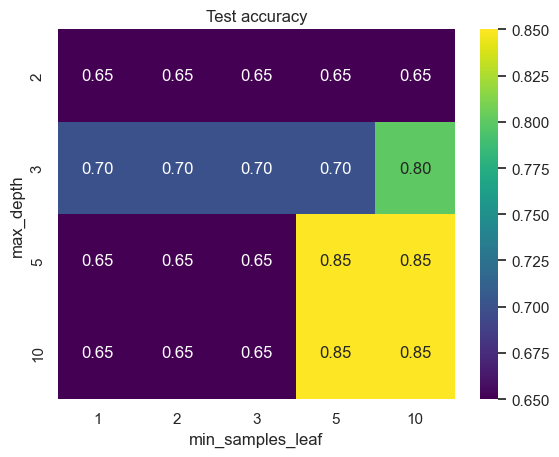

In [21]:
res_pivot = res.pivot(index="max_depth", columns="min_samples_leaf", values="test_acc")

sns.heatmap(res_pivot, annot=True, fmt=".2f", cmap="viridis")
plt.title("Test accuracy")
plt.show()

__Ответ:__

Смещение можно приблизительно оценить значением accuracy на обучающей выборке, так как если модель показывает низкое качество на train, это говорит о том, что модель недообучилась и не может передать структуру данных, то есть модель ещё слишком простая для наших данных.

Разброс можно оценить разностью значений accuracy на обучающей и тестовой выборке, так как если эта разность будет слишком большой, это означает, что модель наоборот переобучилась. То есть из-за своей сложности модель стала слишком чувствительной к данным и потеряла обобщающую способность. 

Тогда выбираем гиперпараметры с лучшим accuracy на обучающей выборке и наименьшим различием с accuracy на трейне. 

Такими гиперпараметрами являются: `max_depth = 5` и `min_samples_leaf = 5`

У этих моделей высокое значение `train_acc = 0.9250` и близкое `test_acc = 0.85` (гораздо лучше по сравнению с моделью из предыдущего пункта, там `test_accuracy = 0.65`)

В целом такими же значения гиперпараметров у модели с `max_depth = 10` и `min_samples_leaf = 5`, но лучше всё таки взять ту, у которой поменьше глубина, чтобы экономику вычилительные ресурсы и минимизировать вероятность переобучения на других данных (у выбранной модели глубина - 5, а у этой - 10)

### Решающие деревья своими руками (6 баллов)

Итак, пришло время реализовать свой класс для обучения решающего дерева.

__Задание 3. (1.5 балла)__

Реализуйте функцию `find_best_split` из модуля `hw5code.py` согласно алгоритму, расказанному на лекции; её сигнатура и докстринг с дополнительными требованиями и указаниями прописаны в файле.

Напоминаем, что под критерием Джини подразумевается следующая функция качества разбиения:

$$
Q(R, R_l, R_r) = -\frac{|R_l|}{|R|} H(R_l) - \frac{|R_r|}{|R|} H(R_r),
$$

где $R$ - множество объектов, $R_l$ и $R_r$ - объекты, попавшие в левое и правое поддерево соответственно.

Функция неоднородности Джини для множества $R$ определяется как

$$
H(R) = 1 - \sum_{k=1}^{K} p_k^2,
$$

где $p_k$ - доля объектов класса $k$ в множестве $R$, а $K$ - число различных классов в текущем узле.

Замечание: при $K=2$ формула сводится к бинарному случаю $H(R)=1-p_0^2-p_1^2$, где $p_1$ и $p_0$ $-$ доля объектов классов $1$ и $0$ соответственно.


Код посылки яндекс контеста: 161213463

Аккаунт: anvimorozova@edu.hse.ru

__Задание 4. (0.75 балл)__

Загрузите датасет [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance). Поработайте с данными: создайте бинарный признак `pass`, который будет равен единице, если итоговая оценка `G3` не меньше $10$, и нулю в противном случае. Затем выберите пять числовых признаков, среди которых должны быть как очень информативные, так и потенциально неинформативные. Коротко обоснуйте свой выбор.

Для каждого из выбранных признаков постройте график зависимости критерия Джини от возможного порога разделения. Отобразите все пять кривых на одном рисунке.

Для каждого из выбранных признаков дополнительно визуализируйте зависимость
"значение признака - класс (0/1)".

> Можно, например, построить scatter-график, где по оси X - значение признака, а по оси Y - бинарный признак `pass` (при необходимости используйте небольшой jitter по оси Y и/или прозрачность alpha, чтобы лучше видеть плотность точек); или использовать эквивалентную по смыслу визуализацию (например, `seaborn.stripplot` / `swarmplot`), из которой видно, как распределены значения признака внутри каждого класса.

__Ответ:__


Потенциально информативные признаки:
- `G2` - оценка за прошлый триместр. Чем лучше были прошлые оценки, тем больше вероятность, что это сильный ученик и в будущем он тоже всё хорошо сдаст. (точно так же очень полезным будет `G1` - если и там, и там высокий балл, то больше вероятность, что этот успех не случайность)
- `failures` - количество прошлых проваленных экзаменов. Этот признак может сведетельствовать о том, что ученик безответсвтенный или незамотививрованный, а значит, он в целом плохо пишет экзамены
- `studytime` - показывает число часов в неделю, которое ученик тратит на учёбу. Связь очевидна: чем больше времени человек уделяет учёбе, тем больше вероятность сдать экзамен

Потенциально бесполезные признаки:
- `age` - возраст студента. Хорошо или плохо учиться можно в любом возрасте по разным причинам, например, можно считать, что чем ты старшем, тем сложнее задания тебе дают, но с другой стороны, ты становишься более ответсвенным и лучше готовишься к экзаменам. Так что этот признак особо не должен помогать.
- `romantic` - есть ли романтические отношения. Тут если связь и есть, то очень слабая : возможно отношения замотивируют стать лучше и больше учиться, а возможно наоборот - больше проводить времени с партнёром и меньше уделять времени учёбе. Связь неясная и слабая. 


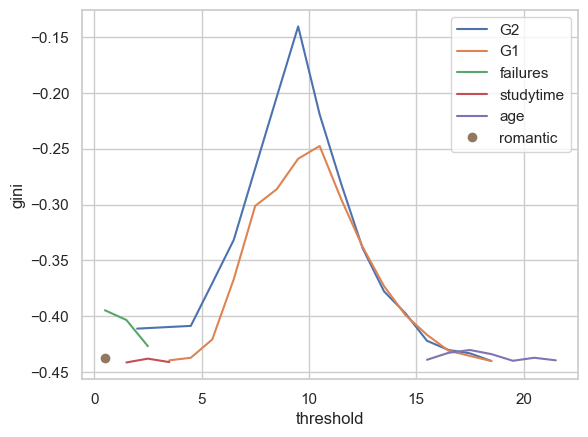

In [48]:
from hw5code import find_best_split

df = pd.read_csv("student\student-mat.csv", sep=";")
df["pass"] = df["G3"] >= 10

features = ["G2", "G1", "failures", "studytime", "age", "romantic"]

X = df[features].copy()
y = df["pass"].copy()
X["romantic"] = (X["romantic"] == "yes").astype(int)

for feature in X.columns:
    thresholds, ginis, _, _ = find_best_split(X[feature].values, y.values)
    
    if len(thresholds) == 1:
        plt.plot(thresholds, ginis, 'o', label=feature)  # точка
    else:
        plt.plot(thresholds, ginis, label=feature)

plt.xlabel("threshold")
plt.ylabel("gini")
plt.legend()
plt.show()


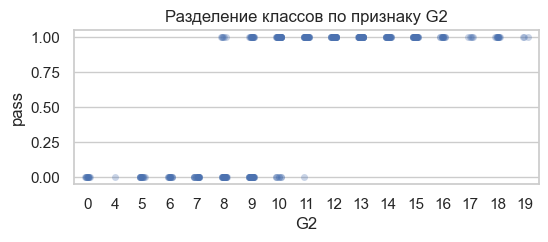

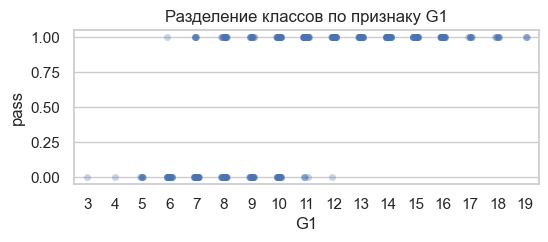

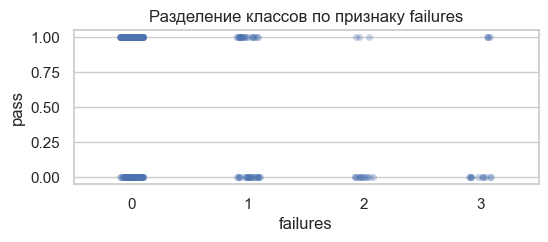

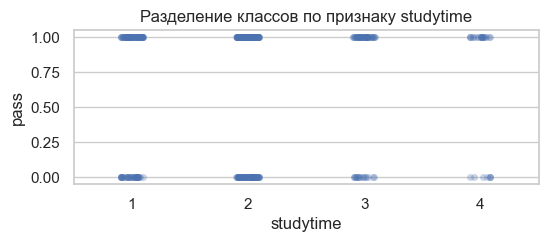

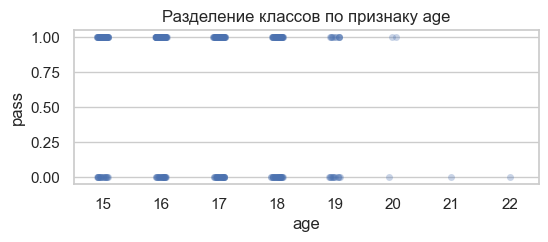

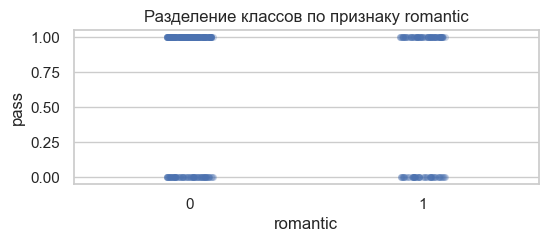

In [52]:
for feature in X.columns:
    plt.figure(figsize=(6, 2))
    sns.stripplot(x=X[feature], y=y, jitter=True, alpha=0.3)
    plt.title(f"Разделение классов по признаку {feature}")
    plt.show()

__Задание 5. (0.25 балла)__

На основании построенных в прошлом задании графиков ответьте на следующие вопросы:

1. По какому признаку нужно производить деление выборки на два поддерева? Почему?

2. Согласуется ли этот результат с тем, что видно на scatter-графиках? Совпадают ли выводы?

3. Как выглядят кривые для тех признаков, по которым классы разделяются почти идеально? Чем отличаются от них кривые для признаков, по которым деление практически невозможно?

**Ответ:**

1) 
Лучше всего разделять по признаку, у которого самый высокий пик джини, то есть это `G2`. Высокий джини означает, что при делении по этому признаку классы внутри поддеревьев довольно равномерные, то есть удалось уловить какую то важную особенность данных.

2) 
Да, это хорошо согласуется с точечным графиком для `G2`, так как при низких порогах почти все точки были сконцентрированы в классе тех, кто не сдал, при высоких порогах - наоборот все сдавали, и только при средних порогах классы были перемешаны. То есть при таком разделении мы путаем только похожие объекты. 

Обратное происходило для признаков с низким джини: классы перемешаны, и сложно выбрать значения, до которого большинство относится к одному классу, а после которого - к дркгому. Это хорошо видно, например, у `romantic`

3) 
Кривые хорошо разделяющих признаков отличаются тем, что у них есть чётко выраженный, острый и высокий пик, как раз как 
у `G2`. Это связано с тем, что если правда будет хороший разделитель, то джини вырастет квадратично от улучшения однородности классов в правом и левом поддеревьях. 

Так же у признаков, которые мне казались полезными (`studetime` и `failures`), кривые тоже с пиком, однако он невысокий. И это можно объяснить с помощью графиков разделения классов: действительно студенты с большим `studetime` чуть реже не сдавали, и студенты с большим `failure` часто проваливали. Однако у этих признаков с одной стороны объекты сильно перемешаны (то есть люди с `failure = 1` одинаково часто сдавали и не сдавали). Да и в целом у этих признаков нет значений с чётким разделениям, так что они оказались слабее, чем я думала.

И у самых бесполезных признаков кривая почти пологая с разными нечётко выраженными пиками, как например, у признака `age`. Так получилось потому что при любом возрасте классы разделяются почти одинаково, поэтому смещение порога не улчшает джини.
Тачно так же с `romance` : у этого признака вообще нет кривой, а лишь точка, потому что это бинарный признак. Но точка находится низко, потому что люди с романтическими отношениями и без почти одинаково сдавали и не сдавали экзамены.



__Задание 6. (1.5 балла)__

Разберитесь с уже написанным кодом в классе `DecisionTree` модуля `hw5code.py`. Исправьте ошибки в методе `_fit_node`, а также реализуйте `_predict_node`.

В данном задании:
* построение дерева осуществляется согласно базовому жадному алгоритму, предложенному на лекции
* выбор лучшего разбиения необходимо производить по критерию Джини
* в качестве критерия останова используется следующий: все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку
* ответ в листе $-$ это наиболее часто встречающийся в нём класс
* для категориальных признаков выполняется преобразование, описанное на лекции (можете найти его в конспекте в разделе «Учёт категориальных признаков»)

__Задание 7. (0.5 балла)__

Протестируйте написанное вами решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). Для этого необходимо скачать таблицу agaricus-lepiota.data и применить к каждому столбцу LabelEncoder, чтобы преобразовать строковые имена категорий в натуральные числа.

Первый столбец в рассматриваемой таблице $-$ это целевая переменная ('e' $-$ edible, 'p' $-$ poisonous).

Обучите решающее дерево на $50\%$ случайно выбранных объектов и получите предсказания для оставшейся половины. Вычислите accuracy. Если в предыдущих заданиях вы всё сделали корректно, то у вас должно получиться качество очень близкое единице или даже равное ей.

In [56]:
from sklearn.preprocessing import LabelEncoder
import importlib
import hw5code
importlib.reload(hw5code)

from hw5code import DecisionTree

data = pd.read_csv("agaricus-lepiota.data", header=None)

X = data.copy()
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

y = X.iloc[:, 0]
X = X.iloc[:, 1:]

X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, stratify=y, test_size=0.5, random_state=42)

tree = DecisionTree(["categorical"] * X.shape[1])
tree.fit(X_train, y_train)

y_predict = tree.predict(X_test)
acc = accuracy_score(y_test, y_predict)
print(f"Accuracy = {acc}")

Accuracy = 1.0


__Задание 8. (1 балл)__

Реализуйте в классе `DecisionTree` поддержку параметров `max_depth`, `min_samples_split` и `min_samples_leaf` по аналогии с `sklearn.tree.DecisionTreeClassifier`.

Айди посылкы в яндекс контесте: 161215768

Аккаунт: anvimorozova@edu.hse.ru

__Задание 9. (0.5 балла)__

Проверьте, спасают эти параметры вас от переобучения.

Для этого **решите при помощи собственной имплементации `DecisionTree`  задачу классификации цвета вина** (color) по его химическим характеристикам на датасете [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality).

Как обычно, случайно разбейте свой датасет на тест-трейн (в отношении 7:3), и далее сравните на них поведение двух деревьев:
- Для первого дерева не используйте параметры из задания 8
- Для второго дерева выберите разумные значения этих параметров (в этом конкретном случае мы рекомендуем `max_depth=8, min_samples_leaf=5, min_samples_split=17`), и постройте дерево с их использованием.
  - Подбирать оптимальные параметры здесь не требуется

Выведите метрики качества классификации. **Что вы наблюдаете, и почему так произошло?**


В качестве sanity check сравните качество работы и структуру вашего второго дерева с результатом стандартной имплементации из `sklearn`. Не забудьте подать ему на вход те же параметры.

**Обратите внимание, что в оригинале таргетом является качество вина; мы же с вами предсказываем его цвет.** В каком-то смысле, это модель-сомелье.


*Андер-сэмплирование данных далее сделано специально, чтобы продемонстрировать должный эффект. Убирать его запрещается.*

In [105]:
from ucimlrepo import fetch_ucirepo

np.random.seed(0)

wine_quality = fetch_ucirepo(id=186)

In [106]:

df = wine_quality.data.original.sample(frac=0.1)

X = df.drop(columns=['color'])
y = df['color']


In [107]:
X.info()

<class 'pandas.DataFrame'>
Index: 650 entries, 5316 to 5545
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         650 non-null    float64
 1   volatile_acidity      650 non-null    float64
 2   citric_acid           650 non-null    float64
 3   residual_sugar        650 non-null    float64
 4   chlorides             650 non-null    float64
 5   free_sulfur_dioxide   650 non-null    float64
 6   total_sulfur_dioxide  650 non-null    float64
 7   density               650 non-null    float64
 8   pH                    650 non-null    float64
 9   sulphates             650 non-null    float64
 10  alcohol               650 non-null    float64
 11  quality               650 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 66.0 KB


In [108]:
y.info()

<class 'pandas.Series'>
Index: 650 entries, 5316 to 5545
Series name: color
Non-Null Count  Dtype
--------------  -----
650 non-null    str  
dtypes: str(1)
memory usage: 10.2 KB


In [113]:
from sklearn.tree import DecisionTreeClassifier

import importlib
import hw5code
importlib.reload(hw5code)

X_train, X_test, y_train, y_test = train_test_split(X.values, y.values, stratify=y, test_size=0.3, random_state=42)

tree_1 = DecisionTree(["real"] * X.shape[1])
tree_1.fit(X_train, y_train)
y1_predict = tree_1.predict(X_test)
acc_1 = accuracy_score(y_test, y1_predict)
print(f"Без параметров останова accuracy = {acc_1}")

tree_2 = DecisionTree(["real"] * X.shape[1], max_depth=8, min_samples_leaf=5, min_samples_split=17)
tree_2.fit(X_train, y_train)
y2_predict = tree_2.predict(X_test)
acc_2 = accuracy_score(y_test, y2_predict)
print(f"С параметрами останова accuracy = {acc_2}")

tree_sk1 = DecisionTreeClassifier(random_state=42)
tree_sk1.fit(X_train, y_train)
y_sk1_predict = tree_sk1.predict(X_test)
acc_sk1 = accuracy_score(y_test, y_sk1_predict)
print(f"У реализации из sklearn без останова = {acc_sk1}")

tree_sk2 = DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=17, random_state=42)
tree_sk2.fit(X_train, y_train)
y_sk2_predict = tree_sk2.predict(X_test)
acc_sk2 = accuracy_score(y_test, y_sk2_predict)
print(f"У реализации из sklearn с остановом = {acc_sk2}")

Без параметров останова accuracy = 0.958974358974359
С параметрами останова accuracy = 0.9538461538461539
У реализации из sklearn без останова = 0.9948717948717949
У реализации из sklearn с остановом = 0.9743589743589743


In [115]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y1_predict))
print()
print(classification_report(y_test, y2_predict))

              precision    recall  f1-score   support

         red       0.98      0.85      0.91        47
       white       0.95      0.99      0.97       148

    accuracy                           0.96       195
   macro avg       0.97      0.92      0.94       195
weighted avg       0.96      0.96      0.96       195


              precision    recall  f1-score   support

         red       1.00      0.81      0.89        47
       white       0.94      1.00      0.97       148

    accuracy                           0.95       195
   macro avg       0.97      0.90      0.93       195
weighted avg       0.96      0.95      0.95       195



Поскольку в нашем случае модели и так очень хорошо обучались, с довольно высоким accuracy, критерии останова только слегка снизили их качество - не дали моделям стать достаточно сложными, чтобы передавать структуру данных.

Ещё тут возможно дело в том, что в датасете сильный дисбаланс классов: красных вин - 47, а белых 148. Поэтому при добавлении параметров останова моделям стало сложнее отделять более мелкие классы, то есть как раз красные вина. Из-за этого у моего дерева с параметрами у красных вин precision = 1, то есть если модель выявила красное вино, то оно точно красное. Также у белых вин стал recall = 1, то есть выявляются абсолютно все белые вина. Это означает, что параметры останова привели к тому, что все пограничные объекты попадали в более широких класс белых вин.

В целом если мы по каким-то причинам так и хотим: с большей точностью выявить красное вино, имеет смысл ставить такие параметры. Однако это сильнее уменьшает recall красного вина, из-за чего f1-score слегка падает.

## Bias-variance decomposition (3 балла)

В этой части задания воспользуемся возможностями бутстрапа для оценки смещения и разброса алгоритмов машинного обучения.

В этом разделе мы будем работать с датасетом `California housing` из `sklearn.datasets.fetch_california_housing`. Это задача регрессии: по признакам района (доход, возраст домов и т.п.) нужно предсказать MedHouseVal - медианная стоимость жилья.

In [74]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
X = california["data"]
y = california["target"]

X.shape, y.shape

((20640, 8), (20640,))

Во всех заданиях этого раздела (задания 10-11) используйте одни и те же данные `X, y` и три стандартные модели из sklearn:

* `LinearRegression`
* `DecisionTreeRegressor`
* `RandomForestRegressor`

Все три модели имеют единый интерфейс, что позволит передавать их в общие функции.


### Вычисление bias и variance (1.5 балл)

На [лекции](https://github.com/esokolov/ml-course-hse/blob/master/2024-fall/lecture-notes/lecture08-ensembles.pdf) была выведена следующая формула, показывающая, как можно представить ошибку алгоритма регрессии в виде суммы трех компонент:
$$
L(\mu) =
    \mathbb{E}_{x, y}\bigl[\mathbb{E}_{X}\bigl[ (y - \mu(X)(x))^2 \bigr]\bigr] =
$$

$$
    \underbrace{\mathbb{E}_{x, y}\bigl[(y - \mathbb{E}[y|x] )^2\bigr]}_{\text{шум}} + \underbrace{\mathbb{E}_{x}\bigl[(\mathbb{E}_{X}[\mu(X)(x)] - \mathbb{E}[y|x] )^2\bigr]}_{\text{смещение}} +
    \underbrace{\mathbb{E}_{x}\bigl[\mathbb{E}_{X}\bigl[(\mu(X)(x) - \mathbb{E}_{X}[\mu(X)(x)] )^2\bigr]\bigr]}_{\text{разброс}},
$$
* $\mu(X)$ — алгоритм, обученный по выборке $X = \{(x_1, y_1), \dots (x_\ell, y_\ell)\}$;
* $\mu(X)(x)$ — ответ алгоритма, обученного по выборке $X$, на объекте $x$;
* $\mathbb{E}_{X}$ — мат. ожидание по всем возможным выборкам;
* $\mathbb{E}_{X}[\mu(X)(x)]$ — "средний" ответ алгоритма, обученного по всем возможным выборкам $X$, на объекте $x$.
    
С помощью этой формулы мы можем анализировать свойства алгоритма обучения модели $\mu$, если зададим вероятностную модель порождения пар $p(x, y)$.

В реальных задачах мы, конечно же, не знаем распределение на парах объект - правильный ответ. Однако у нас есть набор семплов из этого распределения (обучающую выборка), и мы можем использовать его, чтобы оценивать математические ожидания. Для оценки мат. ожиданий по выборкам мы будем пользоваться бутстрэпом - методом генерации "новых" выборок из одной с помощью выбора объектов с возвращением. Разберем несколько шагов на пути к оценке смещения и разброса.

#### **Приближенное вычисление интегралов**

Для большинства моделей данных и алгоритмов обучения аналитически рассчитать математические ожидания в формулах не удастся. Однако мат. ожидания можно оценивать приближенно. Чтобы оценить математическое ожидание $\mathbb{E}_{\bar z} f(\bar z)$ функции от многомерной случайной величины $\bar z = (z_1, \dots, z_d)$, $\bar z \sim p(\bar z)$, можно сгенерировать выборку из распределения $p(\bar z)$ и усреднить значение функции на элементах этой выборки:
$$\mathbb{E}_{\bar z} f(z) = \int f(\bar z) p(\bar z) d \bar z \approx \frac 1 m \sum_{i=1}^m f(\bar z_i), \, \bar z_i \sim p(\bar z), i = 1, \dots, m.$$

Например, оценим $\mathbb{E}_z z^2,$ $z \sim \mathcal{N}(\mu=5, \sigma=3)$ (из теории вероятностей мы знаем, что
$\mathbb{E}_z z^2 = \sigma^2 + \mu^2 = 34$):

In [75]:
z = np.random.normal(loc=5, scale=3, size=1000)
(z**2).mean()

np.float64(33.67421339200312)

#### **Оценивание $\mathbb{E}_{x, y}$**

Оценить мат. ожидания по $x$ и по $x, y$, встречающиеся во всех трех компонентах разложения, несложно, потому что у нас есть выборка объектов из распределения данных $p(x, y)$:
$$ \mathbb{E}_{x} f(x) \approx \frac 1 N \sum_{i=1}^N f(x_i), \quad
\mathbb{E}_{x, y} f(x, y) \approx \frac 1 N \sum_{i=1}^N f(x_i, y_i),$$
где $N$ - число объектов в выборке, $\{(x_i, y_i)\}_{i=1}^N$ - сама выборка.

#### **Оценивание $\mathbb{E}_X$ с помощью бутстрапа**

Чтобы оценить мат. ожидание по $X$, нам понадобится выборка из выборок:
$$\mathbb{E}_X f(X) \approx \frac 1 s \sum_{j=1}^s f(X_j),$$
где $X_j$ - $j$-я выборка. Чтобы их получить, мы можем воспользоваться бутстрапом - методом генерации выборок на основе выбора объектов с возвращением. Чтобы составить одну выборку, будем $N$ раз выбирать индекс объекта $i \sim \text{Uniform}(1 \dots N)$ и добавлять $i$-ю пару (объект, целевая переменная) в выборку. В результате в каждой выборке могут появиться повторяющиеся объекты, а какие-то объекты могут вовсе не войти в некоторые выборки.

**Почему именно выбор с возвращением?**

В классическом бутстрапе мы считаем, что единственное, что у нас есть про распределение данных $p(x, y)$, - это эмпирическое распределение на нашей выборке: каждый объект имеет вероятность $1/N$. Тогда "новая" обучающая выборка размера $N$ моделируется как $N$ независимых выборов *с возвращением* из этого эмпирического распределения.

Отсюда появляются:
* повторы объектов в бутстрап-выборке,
* и, наоборот, out-of-bag объекты, которые в конкретную бутстрап-выборку не попали.

Повторы не являются ошибкой или "зашумлением" эксперимента - они как раз и отражают то, насколько алгоритм чувствителен к конкретным объектам (в том числе к выбросам). Если бы мы каждый раз просто брали подвыборки без возвращения, мы бы изучали уже немного другую процедуру (скорее subsampling / k-fold CV), а не классический бутстрап.

#### **Итоговый алгоритм оценки смещения и разброса алгоритма $a$**
1. Сгенерировать $s$ выборок $X_j$ методом бутстрапа.
1. На каждой выборке $X_j$ обучить алгоритм $a_j$.
1. Для каждой выборки $X_j$ определить множество объектов $T_j$, не вошедших в нее (out-of-bag). Вычислить предсказания алгоритма $a_j$ на объектах $T_j$.

Поскольку у нас есть только один ответ для каждого объекта, мы будем считать шум равным 0, а $\mathbb{E}[y|x]$ равным имеющемуся правильному ответу для объекта $x$.

Итоговые оценки:
* Смещение: для одного объекта - квадрат разности среднего предсказания и правильного ответа. Среднее предсказание берется только по тем алгоритмам $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего смещения выполнить усреденение смещений по объектам.
* Разброс: для одного объекта - выборочная дисперсия предсказаний алгоритмов $a_j$, для которых этот объект входил в out-of-bag выборку $T_j$. Для получения общего разброса выполнить усреденение разбросов по объектам.
* Ошибка $L$: усреднить квадраты разностей предсказания и правильного ответа по всем выполненным предсказаниям для всех объектов.

В результате должно получиться, что ошибка приблизительно равна сумме смещения и разброса!

Алгоритм также вкратце описан по [ссылке](https://web.engr.oregonstate.edu/~tgd/classes/534/slides/part9.pdf) (слайды 19-21).

__Задание 10.1 (1 балл)__

Реализуйте описанный алгоритм. Обратите внимание, что если объект не вошел ни в одну из out-of-bag выборок, учитывать его в вычислении итоговых величин не нужно. Как обычно, разрешается использовать только один цикл - по выборкам (от 0 до num_runs-1).

In [76]:
def compute_biase_variance(model, X, y, num_runs=1000):

    """
    :param model: sklearn estimator with fit(...) and predict(...) method
    :param X: numpy-array representing training set ob objects, shape [n_obj, n_feat]
    :param y: numpy-array representing target for training objects, shape [n_obj]
    :param num_runs: int, number of samples (s in the description of the algorithm)

    :returns: bias (float), variance (float), error (float)
    each value is computed using bootstrap
    """

    predictions = np.full((num_runs, X.shape[0]), np.nan)

    for i in range(num_runs):
        sample_train = np.random.randint(0, X.shape[0], X.shape[0])
        X_train, y_train = X[sample_train], y[sample_train]
        
        sample_test = np.setdiff1d(np.arange(X.shape[0]), sample_train)
        X_test, y_test = X[sample_test], y[sample_test]

        model.fit(X_train, y_train)
        predictions[i, sample_test] = model.predict(X_test)
    
    expected = np.nanmean(predictions, axis = 0)
    bias = np.nanmean((y - expected) ** 2)
    variance = np.nanmean((predictions - expected) ** 2)
    error = np.nanmean((predictions - y) ** 2)

    return bias, variance, error

__Задание 10.2 (0.25 баллов)__

Оцените смещение, разброс и ошибку для трех алгоритмов с гиперпараметрами по умолчанию: линейная регрессия, решающее дерево, случайный лес.

Проанализируйте полученный результат. Согласуются ли полученные результаты с теми, что обсуждались на занятиях?

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

bias_linear, var_linear, err_linear = compute_biase_variance(LinearRegression(), X, y, num_runs=30)
bias_tree, var_tree, err_tree = compute_biase_variance(DecisionTreeRegressor(), X, y, num_runs=30)
bias_rand, var_rand, err_rand = compute_biase_variance(RandomForestRegressor(n_estimators=10), X, y, num_runs=30)

print(f'Для LinearRegression:')
print(f'bias = {bias_linear:.3f}')
print(f'variance = {var_linear:.3f}')
print(f'error = {err_linear:.3f}')
print()

print(f'Для DecisionTreeRegressor:')
print(f'bias = {bias_tree:.3f}')
print(f'variance = {var_tree:.3f}')
print(f'error = {err_tree:.3f}')
print()

print(f'Для RandomForestRegressor:')
print(f'bias = {bias_rand:.3f}')
print(f'variance = {var_rand:.3f}')
print(f'error = {err_rand:.3f}')
print()

Для LinearRegression:
bias = 0.566
variance = 0.201
error = 0.769

Для DecisionTreeRegressor:
bias = 0.272
variance = 0.276
error = 0.545

Для RandomForestRegressor:
bias = 0.249
variance = 0.042
error = 0.290



**Ответ:**

Да, результаты согласуются. 

У линейной регрессии получилось самое большое смещение, как и должно было быть, потому что линейная модель не сможет передать сложные нелинейные зависимости данных, то есть модель слишком простая для этой структуры. Но благодаря этому она точно не переобучилась и даёт стабильные результаты, то есть значение разброса низкое, как и ожидалось.

У решающего дерева всё наоборот. Посколько модель умеет запоминать сложные структуры данных, у неё низкое смещение - почти в 2 раза ниже, чем у линейной регрессии. А разброс у неё наоборот выше, поскольку из-за своей сложности модель склонна к переобучению и чувствительна к небольшим изменениям в данных. 

Случайный лес это как раз способ справится с переобучением решающего дерева, потому что случайный лес усредняет набор моделей построенных на случайно выбранном множестве объектов и признаков, из-за устреднений разных моделей результат получается стабильным, и мы получаем низкий variance. Однако bias чуть чуть увеличивается из-за того, что мы выкидывали некоторые признаки. Именно такие результаты и получились у моего случайного леса.

__Задание 10.3 (0.25 баллов)__
Постройте бэггинг над всеми тремя моделями (линейная регрессия, решающее дерево, случайный лес). Вспомните обсуждение с лекции о том, во сколько раз в теории бэггинг уменьшает разброс базового алгоритма. Выполняется ли это в ваших экспериментах? Если нет, поясните, почему.

**Ответ:**

In [85]:
from sklearn.ensemble import BaggingRegressor

bag_linear = BaggingRegressor(estimator=LinearRegression(), n_estimators=10, random_state=42)
bag_tree = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=10, random_state=42)
bag_rand = BaggingRegressor(estimator=RandomForestRegressor(n_estimators=10), n_estimators=10, random_state=42)

bias_bag_linear, var_bag_linear, err_bag_linear = compute_biase_variance(bag_linear, X, y, num_runs=30)
bias_bag_tree, var_bag_tree, err_bag_tree = compute_biase_variance(bag_tree, X, y, num_runs=30)
bias_bag_rand, var_bag_rand, err_bag_rand = compute_biase_variance(bag_rand, X, y, num_runs=30)

print(f'Для LinearRegression с бэггингом:')
print(f'bias = {bias_bag_linear:.3f}')
print(f'variance = {var_bag_linear:.3f}')
print(f'error = {err_bag_linear:.3f}')
print()

print(f'Для DecisionTreeRegressor с бэггингом:')
print(f'bias = {bias_bag_tree:.3f}')
print(f'variance = {var_bag_tree:.3f}')
print(f'error = {err_bag_tree:.3f}')
print()

print(f'Для RandomForestRegressor с бэггингом:')
print(f'bias = {bias_bag_rand:.3f}')
print(f'variance = {var_bag_rand:.3f}')
print(f'error = {err_bag_rand:.3f}')
print()

Для LinearRegression с бэггингом:
bias = 0.564
variance = 0.031
error = 0.599

Для DecisionTreeRegressor с бэггингом:
bias = 0.251
variance = 0.042
error = 0.291

Для RandomForestRegressor с бэггингом:
bias = 0.256
variance = 0.012
error = 0.267



В теории если усредняются полностью независимые модели , то разброс должен снизится в число раз, равное количеству усредняемых моделей (то есть в моём случае в 10 раз). Однако модели не могут быть совсем независимыми, поскольку обучаются на выборках из одного датасета. Поэтому на самом деле variance снизится в меньшее количество раз.

Ровно это я и получила у своих моделей: bias у всех почти не изменился, а variance сильно снизился, из-за чего и ошибка сильно снизилась почти до уровня bias.

Variance упал:
- для `LinearRegression` с `0.201` до `0.031`           (в 6,28 раз)
- для `DecisionTreeRegressor` с `0.276` до `0.042`      (в 6,57)
- для `RandomForestRegressor` с `0.042` до `0.012`      (в 4 раза)

В итоге, сильнее всего variance упал у `DecisionTreeRegressor`, потому что это была самая переобученная модель с большим изначальным разбросом. У `LinearRegression` variance упал почти так же. А вот у `RandomForestRegressor` меньше всех, потому что это уже изначально была устойчивая модель, в которой применялся механизм усреднения, поэтому от дополнительного бэггинга эффект будет меньше, чем у других моделей.

### Визуализация предсказаний базовых алгоритмов бэггинга (1.5 балл)

Мы уже неоднократно обращались к известной иллюстрации, визуализирующей алгоритмы с разным смещением и разбросом.

![](https://nvsyashwanth.github.io/machinelearningmaster/assets/images/bias_variance.jpg)

В этом задании вам предстоит построить похожее изображение для трёх алгоритмов. Вы будете решать задачу одномерной регрессии, поэтому ваши итоговые мишени будут одномерными.

__Задание 11.1 (1 балл)__

Реализуйте функцию `plot_predictions`, которая должна выполнять следующие шаги:

1. Выбор подмножества данных. Случайным образом выберите num_test_objects пар "объект-целевая переменная" из исходных данных X, y. Выбранные объекты образуют тестовую выборку X_test, y_test, остальные - обучающую выборку X_train, y_train.

2. Метод бутстрапа. Сгенерируйте методом бутстрапа num_runs новых выборок из X_train, y_train. На каждой такой выборке обучите алгоритм и сделайте предсказания для объектов X_test.

3. Построение графика. Нарисуйте scatter-график, где по оси абсцисс - номера тестовых объектов от 0 до num_test_objects - 1 (а не сами значения признаков); по оси ординат - предсказания моделей на этих объектах. В итоге должно получиться num_test_objects вертикальных столбиков из точек: для каждого тестового объекта его num_runs предсказаний.

   Для каждого тестового объекта:
   * отметьте все предсказания для него одним цветом (чтобы был виден столбик);
   * истинный ответ y_test для этого объекта отметьте чёрной точкой.

Не забудьте подписать оси, а также добавить заголовок графика.

> *Примечание.* Раскраска предсказаний по тестовым объектам нужна только для удобства: так легче визуально отличать столбики друг от друга. Можно также сделать все предсказания одного цвета, а истинные значения - чёрными.
>
> Если хотите более явно увидеть bias–variance, можно дополнительно построить второй график, где по оси X - номера тестовых объектов, а по оси Y - разница `mean_pred(x_i) − y_i` (оценка bias), и, например, показать разброс предсказаний в виде вертикальных отрезков или доверительных интервалов.
>
> При больших значениях num_runs вместо (или вместе с) отдельных точек допустимо использовать boxplot/violinplot.


In [102]:
def plot_predictions(model, X, y, num_runs=100, num_test_objects=10, title=""):
    sample_test = np.random.choice(X.shape[0], num_test_objects, replace=False)
    sample_rest = np.setdiff1d(np.arange(X.shape[0]), sample_test)

    X_test, y_test = X[sample_test], y[sample_test]
    X_rest, y_rest = X[sample_rest], y[sample_rest]

    for i in range(num_runs):
        sample_train = np.random.randint(0, X_rest.shape[0], X_rest.shape[0])
        X_train, y_train = X_rest[sample_train], y_rest[sample_train]
        model.fit(X_train, y_train)

        axis = np.arange(X_test.shape[0])
        pred = model.predict(X_test)
        plt.scatter(axis, pred, color='pink', alpha=0.5, label='Предсказания' if i == 0 else None)
    
    plt.scatter(np.arange(X_test.shape[0]), y_test, color='black', label='Таргет')
    plt.xlabel('Индексы тестовых объектов')
    plt.ylabel('Предсказания')
    plt.title(title)
    plt.legend()

__Задание 11.2 (0.5 балла)__

Нарисуйте графики для линейной регрессии, решающего дерева и случайного леса в строчку с одинаковой осью ординат. Это поможет корректно проанализировать масштаб разброса у каждого из этих алгоритмов.

Для каждого графика прокомментируйте, как он характеризует смещение и разброс соответствующего алгоритма.

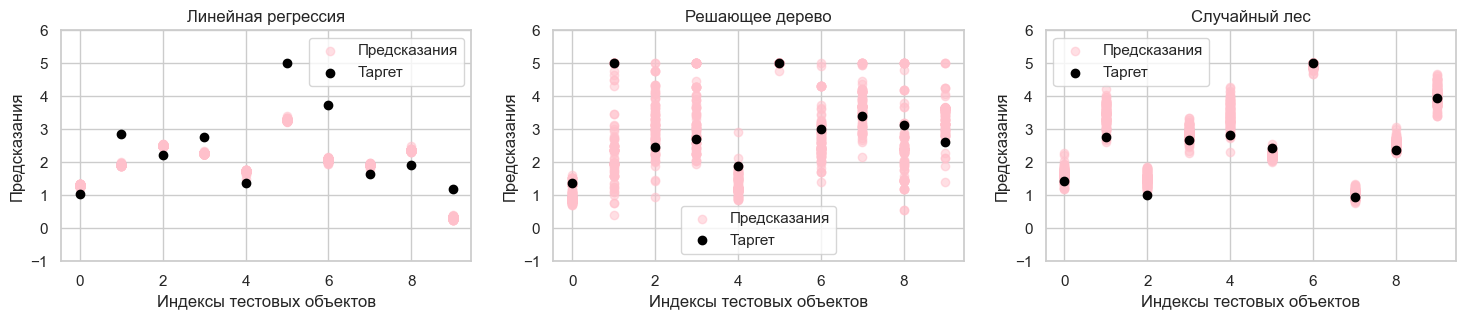

In [104]:
plt.figure(figsize=(18, 3))

plt.subplot(1, 3, 1)
plot_predictions(LinearRegression(), X, y, title="Линейная регрессия")
plt.ylim(-1, 6)

plt.subplot(1, 3, 2)
plot_predictions(DecisionTreeRegressor(), X, y, title="Решающее дерево")
plt.ylim(-1, 6)

plt.subplot(1, 3, 3)
plot_predictions(RandomForestRegressor(n_estimators=10), X, y, title="Случайный лес")
plt.ylim(-1, 6)

plt.show()

**Ответ:**

`LinearRegression`:
- Все точки предсказаний располагаются очень близко друг к другу, почти слиплись в одну точку. Это как раз иллюстрирует то, что у линейных моделей очень маленький разброс.
- При этом точки предсказаний по сравнению с другими моделями находятся стабильно далеко от точек таргета, для некоторых объектов ни одна модель, построенная бутстрапом, не смогла адекватно приблизить таргет. Это говорит о высоком смещении моделей линейной регрессии.

`DecisionTreeRegressor`:
- У многих объектов точки растянулись в длинную полосочку, как например, у второго объекта предсказания почти равномерно распределены от 2 до 5. Это показывает очень высокий разброс модели.
- Однако полоски предсказаний всегда покрывают таргет, и зачастую таргет был примерно посередине выданных предсказаний. Это означает, что по сравнению с линейной регрессией смещение здесь сильно меньше.

`RandomForestRegressor`:
- У случайного леса столбики предсказаний более сжатые и плотные, то есть разброс гораздо лучше, чем у решающего дерева, но всё ещё не такой, как у линейной регрессии. (на том же втором объекте теперь разброс от 1 до 2)
- Со смещение тоже всё хорошо, потому что все столбики покрывают таргет. Возможно чуть похуже, чем у решающего дерева, потому что теперь таргет не в центре распределений предсказаний, а часто с краю, но это незначительно. 